# Sales Funnel Audit Dashboard
**Tools:** Python, Pandas, Matplotlib, Seaborn

**Goal:** Identify where revenue is being lost in a B2B SaaS sales pipeline

**Dataset:** Synthetic CRM data - 1200 leads over 12 months

In [30]:
#importing required packages
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
#setting seed so results are reproducable
np.random.seed(42)
random.seed(42)

## Phase 1: Dataset Generation
Setting up the structural parameters of the sales pipeline before generating records

In [31]:
#Funnel Parameters
n = 1200 #total leads

#defining the satges every deals move through (or falls out of)
stages = ['Lead', 'Qualified', 'Demo', 'Proposal', 'Negotiation', 'Closed Won', 'Closed Lost']

#defining where leads come from, the weights reflex a realistic SaaS marketing mix
sources = ['Organic Search', 'Paid Ads', 'Referral', 'Cold Outreach', 'Social Media']
source_weights = [0.30, 0.25, 0.20, 0.15, 0.10]

#defining customer segments
segments = ['SMB', 'Mid-Market', 'Enterprise']
segment_weights = [0.55, 0.30, 0.15]

#defining sales reps
reps = ['Alex', 'Jordan', 'Morgan', 'Taylor']

print(f"✅ Parameters defined")
print(f" Stages: {stages}")
print(f" Sources: {sources}")
print(f" Segments: {segments}")

✅ Parameters defined
 Stages: ['Lead', 'Qualified', 'Demo', 'Proposal', 'Negotiation', 'Closed Won', 'Closed Lost']
 Sources: ['Organic Search', 'Paid Ads', 'Referral', 'Cold Outreach', 'Social Media']
 Segments: ['SMB', 'Mid-Market', 'Enterprise']


### Generating the Base Records
Creating 1,200 lead records with realistic deal values, dates and assignments

In [32]:
#Building the base dataframe
df = pd.DataFrame({
    'lead_id': [f'LEAD-{i:04d}' for i in range(n)],

    'source': np.random.choice(sources, n, p=source_weights),

    'segment': np.random.choice(segments, n, p=segment_weights),

    # Log-normal distribution gives realistic deal values
    # Most deals are mid-range, a few are very large (like real life)
    'deal_value': np.random.lognormal(8.5, 0.8, n).astype(int),

    # How many days the deal has been sitting in its current stage
    # Exponential distribution — most deals are recent, some are very old
    'days_in_stage': np.random.exponential(12, n).astype(int) + 1,

    'sales_rep': np.random.choice(reps, n),

    # Deals created across a full calendar year
    'created_date': [
        datetime(2023, 1, 1) + timedelta(days=int(x))
        for x in np.random.uniform(0, 365, n)
    ],
})

print("✓ Base DataFrame created")
print(f"  Shape: {df.shape}")
print(f"\nFirst 3 rows:")
df.head(3)

✓ Base DataFrame created
  Shape: (1200, 7)

First 3 rows:


,lead_id,source,segment,deal_value,days_in_stage,sales_rep,created_date
0,LEAD-0000,Paid Ads,Mid-Market,3134,16,Taylor,2023-10-03
1,LEAD-0001,Social Media,SMB,4157,21,Morgan,2023-04-23
2,LEAD-0002,Referral,SMB,1278,2,Taylor,2023-06-13


### Assigning Funnel Stages
Each lead is assigned a stage using realistic SaaS conversion probabilities.
The drop-off rates are based on industry benchmarks and not random

In [33]:
#Assigning stages
# These probabilities reflect real SaaS funnel drop-off rates
# Notice most leads never make it past Lead or Qualified
def assign_stage(row):
    r = random.random()
    if r < 0.30:   return 'Lead'         # 30% never qualify
    if r < 0.55:   return 'Qualified'    # 25% stall at qualified
    if r < 0.70:   return 'Demo'         # 15% don't reach proposal
    if r < 0.80:   return 'Proposal'     # 10% at proposal stage
    if r < 0.85:   return 'Negotiation'  # 5% in negotiation
    if r < 0.92:   return 'Closed Won'   # 7% close — realistic SaaS rate
    return 'Closed Lost'                 # 8% explicitly lost

df['stage'] = df.apply(assign_stage, axis=1)

print("✓ Stages assigned")
print("\nStage distribution:")
print(df['stage'].value_counts())

✓ Stages assigned

Stage distribution:
stage
Lead           361
Qualified      283
Demo           194
Proposal       118
Closed Lost     98
Closed Won      85
Negotiation     61
Name: count, dtype: int64


### Saving the Raw Dataset
Exporting the generated data before any cleaning begins

In [34]:
#saving raw data
df.to_csv('sales_pipeline.csv', index=False)

print("✓ Dataset saved as sales_pipeline.csv")
print(f"\nShape: {df.shape}")
print(f"\nColumn overview:")
print(df.dtypes)
print(f"\nQuick stats on deal value:")
print(df['deal_value'].describe().apply(lambda x: f"${x:,.0f}"))

✓ Dataset saved as sales_pipeline.csv

Shape: (1200, 8)

Column overview:
lead_id                  object
source                   object
segment                  object
deal_value                int64
days_in_stage             int64
sales_rep                object
created_date     datetime64[ns]
stage                    object
dtype: object

Quick stats on deal value:
count      $1,200
mean       $6,775
std        $6,951
min          $438
25%        $2,948
50%        $4,884
75%        $8,212
max      $113,662
Name: deal_value, dtype: object


## Phase 2 - Data Cleaning & Exploratory Analysis
Before any analysis can begin, the dataset needs to be validated and prepared. Dirty data produces misleading insights hence cleaning is not a formality but the foundation of trustworthy analysis.

In [35]:
#Loading data and basic checks
df = pd.read_csv('sales_pipeline.csv')

print("Shape:", df.shape)
print("\n── Missing Values ──")
print(df.isnull().sum())
print("\n── Data Types ──")
print(df.dtypes)
print("\n── Stage Counts ──")
print(df['stage'].value_counts())

Shape: (1200, 8)

── Missing Values ──
lead_id          0
source           0
segment          0
deal_value       0
days_in_stage    0
sales_rep        0
created_date     0
stage            0
dtype: int64

── Data Types ──
lead_id          object
source           object
segment          object
deal_value        int64
days_in_stage     int64
sales_rep        object
created_date     object
stage            object
dtype: object

── Stage Counts ──
stage
Lead           361
Qualified      283
Demo           194
Proposal       118
Closed Lost     98
Closed Won      85
Negotiation     61
Name: count, dtype: int64


## Check Findings
The dataset contains 1,200 records across 8 columns with no missing values, this is a clean foundation to work from.
However, data types need correction before any time-based or numerical analysis can be performed reliably.

In [36]:
# created_date is currently a string — convert to datetime for time analysis
df['created_date'] = pd.to_datetime(df['created_date'])

# deal_value should be numeric — coerce forces any bad values to NaN
df['deal_value'] = pd.to_numeric(df['deal_value'], errors='coerce')

#extracting month period because it will be needed for trend analysis later
df['month'] = df['created_date'].dt.to_period('M')

# Confirm fixes
print("✓ Data types corrected")
print(df[['created_date', 'deal_value', 'month']].dtypes)
print(f"\nDate range: {df['created_date'].min().date()} → {df['created_date'].max().date()}")
print(f"Deal value range: ${df['deal_value'].min():,} → ${df['deal_value'].max():,}")

✓ Data types corrected
created_date    datetime64[ns]
deal_value               int64
month                period[M]
dtype: object

Date range: 2023-01-01 → 2023-12-31
Deal value range: $438 → $113,662


## Data Type Corrections
Dates are now properly formatted for time-series analysis. Deal values are confirmed numeric with no coercion failures. The dataset spans a full 12-month period which is sufficient for identifying seasonal pipeline patterns.

In [37]:
#removing bad rows
rows_before = len(df)
# Zero-value deals are data entry errors — no real deal has zero value
df = df[df['deal_value'] > 0]

# Rows missing stage or source cannot be meaningfully analyzed
df = df.dropna(subset=['stage', 'source'])

rows_after = len(df)
rows_removed = rows_before - rows_after

print(f"✓ Cleaning complete")
print(f"  Rows before: {rows_before:,}")
print(f"  Rows removed: {rows_removed}")
print(f"  Rows after: {rows_after:,}")

✓ Cleaning complete
  Rows before: 1,200
  Rows removed: 0
  Rows after: 1,200


### Data Integrity
No records were removed during cleaning, confirming that the dataset is structurally sound. All records have valid deal values, stages and lead sources so every row contributes to the analysis.

In [38]:
#creating derived columns
# Ordered categorical stage — ensures charts sort correctly every time
stage_order = ['Lead', 'Qualified', 'Demo', 'Proposal',
               'Negotiation', 'Closed Won', 'Closed Lost']
df['stage'] = pd.Categorical(df['stage'],
                              categories=stage_order,
                              ordered=True)

# Binary flags — make filtering and aggregation much faster later
df['is_won']    = (df['stage'] == 'Closed Won').astype(int)
df['is_lost']   = (df['stage'] == 'Closed Lost').astype(int)
df['is_active'] = (~df['stage'].isin(['Closed Won','Closed Lost'])).astype(int)

# Deal value buckets — useful for segment analysis
df['value_tier'] = pd.cut(df['deal_value'],
                           bins=[0, 2000, 8000, 30000, float('inf')],
                           labels=['Small', 'Medium', 'Large', 'Enterprise'])

print("✓ Derived columns created")
print(f"\nWon deals:    {df['is_won'].sum():,}")
print(f"Lost deals:   {df['is_lost'].sum():,}")
print(f"Active deals: {df['is_active'].sum():,}")
print(f"\nValue tier distribution:")
print(df['value_tier'].value_counts().sort_index())

✓ Derived columns created

Won deals:    85
Lost deals:   98
Active deals: 1,017

Value tier distribution:
value_tier
Small         150
Medium        734
Large         303
Enterprise     13
Name: count, dtype: int64


### Derived Columns
Four columns added to accelerate analysis:
- Stage is now an ordered categorical so charts will always render in correct funnel sequence without manual sorting.
- Binary flags (is_won, is_lost, is_active) allow instant segmentation without repeated string comparisons.
- Value tier segment deals by size which is essential for understanding whether revenue concentration sits in small volume or large deals.

In [39]:
#Exploratory Summary
print("═" * 50)
print("PIPELINE OVERVIEW")
print("═" * 50)

total_pipeline = df[df['is_active']==1]['deal_value'].sum()
total_won      = df[df['is_won']==1]['deal_value'].sum()
total_leads    = len(df)
win_rate       = df['is_won'].mean() * 100
avg_deal       = df[df['is_won']==1]['deal_value'].mean()
avg_days       = df['days_in_stage'].mean()

print(f"\nTotal leads in dataset:    {total_leads:,}")
print(f"Overall win rate:          {win_rate:.1f}%")
print(f"Total revenue closed:      ${total_won:,.0f}")
print(f"Active pipeline value:     ${total_pipeline:,.0f}")
print(f"Average won deal value:    ${avg_deal:,.0f}")
print(f"Average days in stage:     {avg_days:.1f} days")

print("\n── Win Rate by Lead Source ──")
print((df.groupby('source')['is_won'].mean() * 100)
      .sort_values(ascending=False)
      .apply(lambda x: f"{x:.1f}%"))

print("\n── Average Deal Value by Segment ──")
print(df.groupby('segment')['deal_value'].mean()
      .sort_values(ascending=False)
      .apply(lambda x: f"${x:,.0f}"))

══════════════════════════════════════════════════
PIPELINE OVERVIEW
══════════════════════════════════════════════════

Total leads in dataset:    1,200
Overall win rate:          7.1%
Total revenue closed:      $609,805
Active pipeline value:     $6,854,143
Average won deal value:    $7,174
Average days in stage:     12.1 days

── Win Rate by Lead Source ──
source
Organic Search    7.7%
Cold Outreach     7.7%
Social Media      7.2%
Paid Ads          6.5%
Referral          6.2%
Name: is_won, dtype: object

── Average Deal Value by Segment ──
segment
Mid-Market    $7,098
Enterprise    $6,802
SMB           $6,584
Name: deal_value, dtype: object


### Exploratory Findings
1. Win rate sits at approximately 7% overall which is below the healthy SaaS benchmark of 20-30%. This signals a systematic issue either at the top of the funnel (lead quality) or middle of funnel (demo and proposal effectiveness).
2. The gap between active pipeline value and closed revenue is significant at $6, 854,143 vs $ 609, 805 closed. This indicates substantial revenue that exists on paper but has not yet converted. The ratio between these two numbers will inform pipeline coverage analysis in phase 3.
3. Win rates across lead sources are suprisingly flat, ranging narrowly between 6.2% (Referral) and 7.7% (Organic Search). In most SaaS pipelines, referral typically dominates conversion by a significant margin. This uniformity is worth flagging because it may indicate that lead source alone is not a strong differentiator in this pipeline, or that the qualification process treats all sources identically regardless of their natural intent level.
4. Mid-market deals are outperforming Enterprise on average deal value
($7,098 vs $6,802)  which contradicts standard SaaS expectations.
Enterprise contracts typically command a significant premium due to complexity,customisation, and seat volume. Two hypotheses worth investigating: Enterprise deals in this pipeline may be underpriced
relative to their scope, or the Enterprise sample size (15% of leads) may be too small to produce a statistically reliable average. Either explanation has a meaningful strategic implication.
5. The distinction between what theory predicts and what the data actually shows is where real analysis begins. Both anomalies above: flat source conversion and inverted segment values would be flagged immediiately in a client engagement and would drive the first set of diagnostic questions before any recommendations were made.
These observations form the basis for the metrics and visualizations in Phase 3 and 4.


In [40]:
# SAVE CLEAN DATASET
df.to_csv('pipeline_clean.csv', index=False)
print("✓ pipeline_clean.csv saved")
print(f"  Shape: {df.shape}")
print(f"  Columns: {list(df.columns)}")

✓ pipeline_clean.csv saved
  Shape: (1200, 13)
  Columns: ['lead_id', 'source', 'segment', 'deal_value', 'days_in_stage', 'sales_rep', 'created_date', 'stage', 'month', 'is_won', 'is_lost', 'is_active', 'value_tier']


## Phase 3 - Core Funnel Metrics
Charts without numbers are decoration. This phase calculates the six metrics that a SaaS founder or sales leader would demand before making any strategic decision. Every number produced here has a direct business meaning and a dollar amount attached to it.

### Metric 1 - Stage by Stage Conversion Rates
This is the most important funnel question: What percentage of deals survive each transition. The stage with the lowest conversion rate is the highest leverage point for improvement.

In [41]:
# Metric 1: Stage by Stage Conversion Rates
#only active stages will be measured. Closed Lost is an exit and not a progression
active_stages = ['Lead', 'Qualified', 'Demo', 'Proposal', 'Negotiation', 'Closed Won']

#counting how many deals exist at each stage and beyond
stage_counts = {stage: df[df['stage'] >= stage].shape[0]
                for stage in active_stages}

#calculating conversion rates between each consecutive stage pair
conversion_rates = {}
conversion_rates = {}
for i in range(len(active_stages) - 1):
    current = active_stages[i]
    next_s  = active_stages[i + 1]
    rate    = (stage_counts[next_s] / stage_counts[current]) * 100
    conversion_rates[f'{current} → {next_s}'] = round(rate, 1)

print("Stage-by-Stage Conversion Rates:")
print("─" * 40)
for transition, rate in conversion_rates.items():
    bar = "█" * int(rate / 3)
    print(f"{transition:<30} {rate:>5}%  {bar}")

print(f"\nEnd-to-end funnel conversion: {conversion_rates[list(conversion_rates.keys())[0]] * 0:.0f}", end="")
overall = (stage_counts['Closed Won'] / stage_counts['Lead']) * 100
print(f"Overall Lead → Won conversion: {overall:.1f}%")

Stage-by-Stage Conversion Rates:
────────────────────────────────────────
Lead → Qualified                69.9%  ███████████████████████
Qualified → Demo                66.3%  ██████████████████████
Demo → Proposal                 65.1%  █████████████████████
Proposal → Negotiation          67.4%  ██████████████████████
Negotiation → Closed Won        75.0%  █████████████████████████

End-to-end funnel conversion: 0Overall Lead → Won conversion: 15.2%


### Metric 1 Findings - Stage-by-Stage Conversion Rates

The funnel maintains a surprisingly consistent conversion rate across all
transitions, ranging between 65.1% and 75.0%. This uniformity is itself an important finding because it tells us there is no single catastrophic
bottleneck stage where deals collapse en masse. Instead, the pipeline bleeds steadily at every transition.

The steepest drop occurs at Demo → Proposal, where 34.9% of deals that reach a live demonstration never progress to a formal offer. In a real SaaS context this typically signals one of two problems: either the demo
is not connecting the product to the prospect's specific pain points strongly enough to justify a proposal, or sales reps are conducting demos
with prospects who were never qualified deeply enough to be ready for a commercial conversation.

The strongest conversion in the funnel occurs at Negotiation → Closed Won at 75.0%. This means once a deal reaches negotiation, three quarters of them close. This is actually encouraging. It tells us the closing capability
exists. The problem is not that reps cannot close, it is that not enough deals are surviving long enough to reach the closing stage.

The end-to-end Lead → Won conversion of 15.2% sits below the healthy SaaS benchmark of 20-30%. However the consistency across stages suggests this
is not a single-point failure. Improving conversion by just 5 percentage points at each of the three weakest stages:Demo Qualified, and Proposal would compound into a dramatically different overall win rate. Small fixes across multiple stages outperform one large fix at a single stage.

### Metric 2 - Overall Win Rate
Win rate measures the percentage of all entered leads that result in closed revenue. Then SaaS industry benchmark is 20-30% for a healthy pipeline. Below 15% signals a systematic problem.

In [42]:
#Metric 2: Win Rate Analysis
overall_win_rate = df['is_won'].mean() * 100

# Win rate by sales rep — identifies coaching opportunities
rep_performance = (df.groupby('sales_rep')
                     .agg(
                         total_deals = ('lead_id', 'count'),
                         wins        = ('is_won', 'sum'),
                         win_rate    = ('is_won', 'mean'),
                         avg_deal    = ('deal_value', 'mean')
                     )
                     .assign(win_rate = lambda x: x['win_rate'] * 100)
                     .round(1)
                     .sort_values('win_rate', ascending=False))

print(f"Overall Win Rate: {overall_win_rate:.1f}%")
print(f"Industry Benchmark: 20-30%")
print(f"Status: {'⚠ BELOW BENCHMARK' if overall_win_rate < 20 else '✓ HEALTHY'}")
print(f"\n── Win Rate by Sales Rep ──")
print(rep_performance.to_string())

# Best and worst performing rep
best_rep  = rep_performance.index[0]
worst_rep = rep_performance.index[-1]
gap       = rep_performance['win_rate'].max() - rep_performance['win_rate'].min()
print(f"\nTop performer:   {best_rep} ({rep_performance.loc[best_rep,'win_rate']}%)")
print(f"Lowest performer: {worst_rep} ({rep_performance.loc[worst_rep,'win_rate']}%)")
print(f"Performance gap: {gap:.1f} percentage points")

Overall Win Rate: 7.1%
Industry Benchmark: 20-30%
Status: ⚠ BELOW BENCHMARK

── Win Rate by Sales Rep ──
           total_deals  wins  win_rate  avg_deal
sales_rep                                       
Taylor             290    26       9.0    6694.3
Morgan             297    20       6.7    6520.5
Alex               305    20       6.6    7266.5
Jordan             308    19       6.2    6608.9

Top performer:   Taylor (9.0%)
Lowest performer: Jordan (6.2%)
Performance gap: 2.8 percentage points


### Metric 2 Findings - Overall Win Rate & Sales Rep Performance

The overall win rate of 7.1% sits significantly below the SaaS industry benchmark of 20-30%. It is important to distinguish this from the 15.2%
end-to-end funnel conversion calculated in Metric 1. The funnel conversion measures progression efficiency across active stages. The win rate measures reality that is every lead that entered the pipeline, including those explicitly
lost to competitors or budget decisions. The 8.1 percentage point gap between these two figures confirms that a meaningful portion of pipeline
deals are not quietly stalling but they are actively being lost.

At the individual rep level, performance is relatively clustered, with win rates ranging from 6.2% (Jordan) to 9.0% (Taylor) this is a gap of 2.8 percentage points. On the surface this appears modest. However context matters
significantly here. Taylor is closing at a rate 45% higher than Jordan on a per-deal basis. Across 300 deals, that gap translates into approximately 8 additional closed deals which at an average deal value of roughly $6,800 represents over $54,000 in revenue difference between
the top and bottom performer.

Two competing explanations exist for this performance gap and both should be investigated before drawing conclusions. First, lead quality distribution if Jordan is consistently receiving lower quality leads from less productive sources, their win rate disadvantage may reflect territory
allocation rather than skill. Second, if lead distribution is roughly equal across reps, the gap points to a coaching opportunity specifically in the
Demo to Proposal transition where the smallest conversion rates were observed in Metric 1.

Taylor's higher average deal value of $6,694 combined with the strongest win rate makes them the clear benchmark performer. Understanding what Taylor does differently in qualification and demo stages should inform how the rest of the team is coached.


### Metric 3 - Pipeline Value by Stage
Understanding where deal value is concentrated across the funnel reveals both opportunity and risk. High value at early stages represents potential.
High value at late stages with long deal age represents urgent action items.

In [43]:
#Metric 3: Pipeline Value by Stage
# ── METRIC 3: PIPELINE VALUE BY STAGE ────────────────────────────────
pipeline_by_stage = (df.groupby('stage', observed=True)['deal_value']
                       .agg(['sum', 'mean', 'count'])
                       .rename(columns={
                           'sum':   'total_value',
                           'mean':  'avg_value',
                           'count': 'deal_count'
                       }))

# Calculate what percentage of total pipeline each stage represents
pipeline_by_stage['pct_of_pipeline'] = (
    pipeline_by_stage['total_value'] /
    pipeline_by_stage['total_value'].sum() * 100
).round(1)

# Format for display
display = pipeline_by_stage.copy()
display['total_value'] = display['total_value'].apply(lambda x: f"${x:,.0f}")
display['avg_value']   = display['avg_value'].apply(lambda x: f"${x:,.0f}")
display['pct_of_pipeline'] = display['pct_of_pipeline'].apply(lambda x: f"{x}%")

print("Pipeline Value Distribution by Stage:")
print("─" * 60)
print(display.to_string())

total = pipeline_by_stage['total_value'].sum()
print(f"\nTotal pipeline value (all stages): ${total:,.0f}")

Pipeline Value Distribution by Stage:
────────────────────────────────────────────────────────────
            total_value avg_value  deal_count pct_of_pipeline
stage                                                        
Lead         $2,423,589    $6,714         361           29.8%
Qualified    $1,877,308    $6,634         283           23.1%
Demo         $1,211,555    $6,245         194           14.9%
Proposal       $882,572    $7,479         118           10.9%
Negotiation    $459,119    $7,527          61            5.6%
Closed Won     $609,805    $7,174          85            7.5%
Closed Lost    $665,836    $6,794          98            8.2%

Total pipeline value (all stages): $8,129,784


### Metric 3 Findings - Pipeline Value Distribution by Stage
Total pipeline value across all stages stands at $8,129,784. However the
distribution of that value reveals a pipeline that is heavily weighted toward the earliest stages. This is a pattern that carries both opportunity and
significant risk.

The Lead and Qualified stages alone account for $4,300,897 which is 52.9% of total pipeline value and yet these are the stages furthest from revenue realisation. Value sitting at the top of the funnel is potential, not
performance. Until these deals progress through Demo and Proposal, they
represent nothing more than optimistic entries in a CRM.

Two patterns in the stage-by-stage value distribution demand attention.

First, average deal value actually increases as deals progress deeper
into the funnel:rising from $6,714 at Lead stage to $7,527 at Negotiation. This is a healthy signal. It tells us that higher value deals are surviving the funnel at a slightly better rate than lower value deals. This suggests that sales reps are prioritising appropriately as deals progress. A pipeline where average deal value drops toward the bottom would indicate the opposite problem: reps closing easy small deals while larger opportunities stall and die.

Second  and most critically $665,836 in deal value sits in Closed Lost.
This is 8.2% of total pipeline value that has been permanently surrendered to competitors or lost to no-decision outcomes. Notably, this figure is larger than the total Closed Won revenue of $609,805. The pipeline is currently losing more value than it is closing. Every dollar column in
this table is dwarfed by the $6,854,143 sitting in active stages that
has yet to convert in either direction.

The most urgent strategic question this data raises is pipeline velocity how quickly is value moving from the $2,423,589 sitting at Lead stage
toward the bottom of the funnel? Value that does not move becomes the
stalled revenue at risk that Metric 4 will quantify precisely.

### Metric 4 - Revenue at Risk
Stalled deals are the silent destroyers of pipeline health. Any active deal sitting in a stage beyond 30 days without progression is considered at risk. Quantifying this in dollar terms creates urgency for sales leadership to act immediately.

In [44]:
#Metric 4: Revenue at Risk
stall_threshold = 30  # industry standard — 30 days without movement

# Stalled deals are active deals that have exceeded the threshold
stalled = df[(df['is_active'] == 1) &
             (df['days_in_stage'] > stall_threshold)]

revenue_at_risk    = stalled['deal_value'].sum()
total_active_value = df[df['is_active']==1]['deal_value'].sum()
pct_at_risk        = (revenue_at_risk / total_active_value) * 100

# Break down stalled deals by stage — where is the stalling happening?
stalled_by_stage = (stalled.groupby('stage', observed=True)['deal_value']
                            .agg(['sum', 'count'])
                            .rename(columns={'sum':'value_at_risk',
                                           'count':'stalled_deals'}))
stalled_by_stage['value_at_risk'] = stalled_by_stage['value_at_risk'].apply(
    lambda x: f"${x:,.0f}")

print(f"Stall Threshold:     {stall_threshold} days")
print(f"Stalled Deals:       {len(stalled):,}")
print(f"Revenue at Risk:     ${revenue_at_risk:,.0f}")
print(f"% of Active Pipeline: {pct_at_risk:.1f}%")
print(f"\n── Stalled Deals by Stage ──")
print(stalled_by_stage.to_string())

# Recoverable revenue estimate — based on average win rate
recoverable = revenue_at_risk * (overall_win_rate / 100)
print(f"\nIf actioned immediately, estimated recoverable revenue:")
print(f"${recoverable:,.0f} (based on {overall_win_rate:.1f}% win rate)")

Stall Threshold:     30 days
Stalled Deals:       85
Revenue at Risk:     $507,185
% of Active Pipeline: 7.4%

── Stalled Deals by Stage ──
            value_at_risk  stalled_deals
stage                                   
Lead             $187,534             25
Qualified        $121,877             23
Demo              $73,343             15
Proposal          $75,970             12
Negotiation       $48,461             10

If actioned immediately, estimated recoverable revenue:
$35,926 (based on 7.1% win rate)


### Metric 4 Findings — Revenue at Risk from Stalled Deals

85 active deals have exceeded the 30-day stall threshold, representing
$507,185 in pipeline value that is neither progressing nor formally lost.
This is the most operationally urgent finding in the entire analysis because stalled deals do not stay stalled indefinitely. They die quietly, disappearing from the pipeline without ever appearing in the Closed Lost column, which means their failure never gets examined or learned from.

At 7.4% of total active pipeline, the stalled value may appear contained. But that framing understates the problem in two important ways.

First, stalled deals decay exponentially and not linearly. A deal that has
been sitting at Proposal for 35 days is not slightly worse than one that has been there for 20 days. Research consistently shows that deal conversion probability drops by roughly half after 30 days of inactivity,
and continues falling sharply with every additional week. The $507,185
figure represents today's value. Left unactioned for another 30 days, the recoverable portion of that number will be a fraction of what it is
right now.

Second, the stage distribution of stalled deals reveals top-of-funnel
concentration problem. Lead and Qualified stages account for 48 of the
85 stalled deals — $309,411 of the $507,185 at risk. Stalling at these
early stages is particularly damaging because it blocks pipeline capacity.
Sales reps are spending time maintaining relationships with deals that have gone cold at the very beginning of the funnel, leaving less capacity for progressing deals that are genuinely alive deeper in the pipeline.

The Negotiation stage presents the most disproportionate risk. With 10 stalled deals worth $48,461, these are the closest deals to generating revenue in the entire pipeline. A deal that has survived Lead,
Qualification, Demo, and Proposal only to stall at Negotiation has already
consumed the majority of the sales cycle's time and resources. Losing it
at this stage is the most expensive possible outcome — all the investment
with none of the return.

Based on the current win rate of 7.1%, immediate action on all 85 stalled
deals could recover an estimated $35,926 in revenue. This estimate is
deliberately conservative as it applies the overall pipeline win rate
uniformly. In practice, deals that have already reached Proposal and
Negotiation have already cleared the hardest qualification hurdles and
would be expected to convert at a meaningfully higher rate than the
pipeline average. The true recoverable figure for late-stage stalled
deals is likely two to three times this estimate.

The recommended immediate action is a two-tier intervention: a same-week
outreach sprint targeting all 10 stalled Negotiation deals as the highest
priority, followed by a structured re-qualification of the 25 stalled
Lead-stage deals to determine which should be formally closed lost and
removed from the pipeline entirely. A clean pipeline is more valuable
than a large one.

### Metric 5 — Win Rate by Lead Source
Not all leads are created equal. This metric reveals which acquisition
channels produce deals that actually close. The difference between
volume and value. Misreading this leads companies to overspend on
channels that look productive but don't convert.

In [45]:
#Metric 5: Win rate by lead source
source_analysis = (df.groupby('source')
                     .agg(
                         total_leads  = ('lead_id', 'count'),
                         wins         = ('is_won', 'sum'),
                         win_rate     = ('is_won', 'mean'),
                         avg_deal_val = ('deal_value', 'mean'),
                         total_value  = ('deal_value', 'sum')
                     )
                     .assign(win_rate = lambda x: x['win_rate'] * 100)
                     .round(1)
                     .sort_values('win_rate', ascending=False))

# Revenue generated per lead — the most important efficiency metric
source_analysis['revenue_per_lead'] = (
    df[df['is_won']==1]
    .groupby('source')['deal_value'].sum() /
    source_analysis['total_leads']
).round(0)

print("Lead Source Performance:")
print("─" * 70)
print(source_analysis[['total_leads','wins','win_rate',
                        'avg_deal_val','revenue_per_lead']].to_string())

best_source  = source_analysis.index[0]
worst_source = source_analysis.index[-1]
multiplier   = (source_analysis.loc[best_source, 'win_rate'] /
                source_analysis.loc[worst_source, 'win_rate'])
print(f"\nBest converting source:  {best_source} ({source_analysis.loc[best_source,'win_rate']}%)")
print(f"Worst converting source: {worst_source} ({source_analysis.loc[worst_source,'win_rate']}%)")
print(f"Conversion multiplier:   {multiplier:.1f}x")

Lead Source Performance:
──────────────────────────────────────────────────────────────────────
                total_leads  wins  win_rate  avg_deal_val  revenue_per_lead
source                                                                     
Cold Outreach           183    14       7.7        5881.9             419.0
Organic Search          376    29       7.7        7398.4             603.0
Social Media            125     9       7.2        6480.4             495.0
Paid Ads                276    18       6.5        6840.3             523.0
Referral                240    15       6.2        6556.8             417.0

Best converting source:  Cold Outreach (7.7%)
Worst converting source: Referral (6.2%)
Conversion multiplier:   1.2x


### Metric 5 Findings — Win Rate by Lead Source

Lead source performance across all five acquisition channels is
remarkably uniform, ranging from 6.2% (Referral) to 7.7% (Cold Outreach). This is a spread of just 1.5 percentage points. The conversion multiplier
between best and worst performing source stands at only 1.2x. In a
pipeline of this size, this difference is not statistically meaningful
enough to drive budget reallocation decisions on conversion rate alone.

This finding contradicts the standard SaaS expectation that Referral
leads convert at significantly higher rates than other channels. In most B2B pipelines, referral leads arrive pre-qualified by trust for example a colleague or partner has already vouched for the product, dramatically shortening
the qualification conversation and increasing close probability. The fact
that Referral ranks last here at 6.2% suggests one of three possibilities:
the referral programme is generating leads of inconsistent quality,
referred leads are being handled identically to cold leads rather than
receiving a tailored high-touch process, or the sample of 240 referral
leads is insufficiently large to surface the conversion advantage that
theory predicts.

Where lead sources do differentiate meaningfully is in revenue per lead, a more complete efficiency metric that combines conversion rate with
average deal value. On this measure, Organic Search emerges as the
strongest channel, generating $603 in revenue per lead against a pipeline average of $491. This is driven not by superior conversion rate but by deal quality therefore Organic Search produces the highest average deal value at
$7,398, suggesting that prospects arriving via organic search have greater budget authority or stronger commercial intent than those arriving through other channels.

Cold Outreach presents an interesting profile. It matches Organic Search
on win rate at 7.7% but produces the lowest average deal value at $5,882 and the lowest revenue per lead at $419. This is a common Cold Outreach
pattern as reps close frequently but on smaller, easier deals. The volume
efficiency looks strong until deal value is factored in.

Paid Ads deserves specific scrutiny. At 276 leads it represents the
second largest volume channel and the second highest budget commitment
for most SaaS companies yet it produces a below average win rate of
6.5% and a revenue per lead of $523 that sits in the middle of the pack.
Without knowing the actual spend behind this channel, a definitive
efficiency judgment cannot be made. However the combination of high
volume, moderate deal value and below average conversion warrants a
detailed cost-per-acquisition review before the next budget cycle.

The most actionable finding from this metric is not which source to
prioritise because the conversion data is too uniform for that conclusion.
The real finding is that this pipeline's performance is not being
differentiated by lead source at all. A well-functioning pipeline should show Referral converting at 2-3x the rate of Cold Outreach. The absence of that differentiation suggests the qualification and nurturing process
is treating all leads identically regardless of their origin — which is
both an opportunity and an inefficiency worth addressing.

### Metric 6 — Deal Value by Segment
Understanding which customer segment generates the most value  and
converts most reliably is fundamental to sales resource allocation.
Chasing the wrong segment is one of the most expensive mistakes a
growing SaaS company can make.

In [46]:
#Metric 6: Deal value and performance by segment
segment_analysis = (df.groupby('segment')
                      .agg(
                          total_leads  = ('lead_id', 'count'),
                          wins         = ('is_won', 'sum'),
                          win_rate     = ('is_won', 'mean'),
                          avg_value    = ('deal_value', 'mean'),
                          total_value  = ('deal_value', 'sum'),
                          avg_days     = ('days_in_stage', 'mean')
                      )
                      .assign(win_rate = lambda x: x['win_rate'] * 100)
                      .round(1)
                      .sort_values('avg_value', ascending=False))

# Expected value per lead — win rate × average deal value
segment_analysis['expected_value'] = (
    segment_analysis['win_rate'] / 100 *
    segment_analysis['avg_value']
).round(0)

print("Segment Performance Analysis:")
print("─" * 70)
print(segment_analysis.to_string())

print("\n── Strategic Interpretation ──")
for seg in segment_analysis.index:
    ev = segment_analysis.loc[seg, 'expected_value']
    wr = segment_analysis.loc[seg, 'win_rate']
    av = segment_analysis.loc[seg, 'avg_value']
    print(f"{seg:<12} Win Rate: {wr}%  Avg Deal: ${av:,.0f}  Expected Value/Lead: ${ev:,.0f}")

Segment Performance Analysis:
──────────────────────────────────────────────────────────────────────
            total_leads  wins  win_rate  avg_value  total_value  avg_days  expected_value
segment                                                                                  
Mid-Market          373    26       7.0     7098.3      2647654      11.7           497.0
Enterprise          170    10       5.9     6802.3      1156396      12.7           401.0
SMB                 657    49       7.5     6584.1      4325734      12.2           494.0

── Strategic Interpretation ──
Mid-Market   Win Rate: 7.0%  Avg Deal: $7,098  Expected Value/Lead: $497
Enterprise   Win Rate: 5.9%  Avg Deal: $6,802  Expected Value/Lead: $401
SMB          Win Rate: 7.5%  Avg Deal: $6,584  Expected Value/Lead: $494



### Metric 6 Findings — Deal Value & Performance by Segment

The segment analysis produces the most strategically significant finding
of the entire metric suite — and it directly contradicts the resource
allocation assumption most SaaS sales teams operate under.

Enterprise is the worst performing segment across every meaningful
metric. At a 5.9% win rate, Enterprise deals close less frequently than
both SMB and Mid-Market. At $6,802 average deal value, Enterprise
contracts are worth less than Mid-Market deals despite carrying
significantly higher sales complexity, longer cycles, and greater resource
demands. The resulting expected value per lead of $401 sits $96 below
Mid-Market and $93 below SMB — meaning every Enterprise lead in this
pipeline generates less expected revenue than a lead from either of the
other two segments.

This finding demands explanation before it drives action. Three hypotheses
are worth investigating. First, Enterprise deals in this pipeline may be
systematically underpriced — contracted at rates that do not reflect the
true complexity and customisation they require. If this is the case, the
fix is commercial, not operational. Second, the Enterprise sample of 170
leads representing 14.2% of the pipeline may be too small to produce
statistically reliable averages — a larger Enterprise pipeline might
reveal the premium deal values that theory predicts. Third, the sales
team may lack the specific skills Enterprise deals require. Enterprise
selling is a fundamentally different motion from SMB or Mid-Market — it
requires multi-stakeholder navigation, procurement management, and
extended relationship building that generalist reps rarely excel at.

SMB emerges as the pipeline's unexpected engine. With 657 leads, a 7.5%
win rate, and the fastest average deal progression at 12.2 days, SMB
generates more closed deals than any other segment and moves through the
pipeline with the least friction. The total SMB pipeline value of
$4,325,734 represents 53.2% of all pipeline value — making it by far the
largest revenue pool in the business. In a pipeline suffering from
stalling problems and a below-benchmark overall win rate, SMB's velocity
advantage is commercially significant. Fast-moving deals consume less
sales capacity per dollar of revenue generated.

Mid-Market represents the strategic sweet spot. The highest average deal
value at $7,098, a competitive win rate of 7.0%, and the highest expected
value per lead at $497 make it the most efficient segment when both
quality and conversion are considered together. Mid-Market deals are worth
more than SMB deals and close more reliably than Enterprise deals — the
combination that every SaaS sales leader is looking for.

The strategic implication is direct. Current resource allocation almost
certainly skews toward Enterprise — larger deals attract disproportionate
sales attention in most organisations regardless of what the conversion
data shows. This pipeline's numbers suggest that rebalancing sales effort
toward Mid-Market as the primary growth segment, while maintaining SMB
volume for pipeline velocity, would produce better revenue outcomes than
continuing to invest heavily in Enterprise deals that are currently
converting at the lowest rate for the lowest average value.

A separate Enterprise diagnostic — focused on pricing, rep capability,
and pipeline stage timing — is warranted before any further investment
in Enterprise lead generation is approved.

### Phase 3 Summary — The Business Picture

Six metrics. One consistent narrative.

This pipeline has a conversion problem that is evenly distributed across
stages, a stalling problem concentrated at the top of the funnel, and a
segment allocation problem hiding in plain sight. The three findings that
will drive the recommendations in the Insight Brief are:

1. The overall win rate of 7.1% is less than half the SaaS benchmark
   minimum of 15% — but the consistency of stage-by-stage conversion
   rates between 65-75% suggests the fix is not dramatic. Incremental
   improvement across multiple stages will compound into a materially
   different overall win rate.

2. $507,185 in active pipeline value has stalled beyond the 30-day
   threshold. The 10 stalled Negotiation deals represent the highest
   priority intervention — they are the closest to revenue and have
   already absorbed the full cost of the sales cycle.

3. Enterprise underperforms SMB and Mid-Market on win rate, deal value,
   and expected value per lead simultaneously — suggesting a fundamental
   misalignment between where sales resources are being invested and
   where the pipeline data shows returns are actually being generated.

These three findings form the complete analytical foundation for the
visualizations in Phase 4 and the business recommendations in Phase 5.

## Phase 4 — Visualizations
Five charts. Each one answers a specific business question that a founder or sales leader would ask in a board meeting. The goal is not decoration but compression. Every insight from Phase 3 distilled into something
that can be understood in under 10 seconds.

In [47]:
#Theme setup
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

#Colour palette
COLORS = {
    'primary'  : '#22d3a0',   # teal green — main bars/lines
    'secondary': '#38bdf8',   # sky blue — secondary lines
    'warn'     : '#f59e0b',   # amber — risk/problems
    'danger'   : '#f87171',   # red — lost/bad
    'bg'       : '#0d1117',   # near-black background
    'surface'  : '#161b22',   # slightly lighter surface
    'text'     : '#e6edf3',   # near-white text
    'muted'    : '#7d8590',   # grey labels
    'grid'     : '#21262d',   # subtle grid lines
}

#global matplotlab settings
plt.rcParams.update({
    'figure.facecolor'    : COLORS['bg'],
    'axes.facecolor'      : COLORS['surface'],
    'axes.labelcolor'     : COLORS['muted'],
    'axes.titlecolor'     : COLORS['text'],
    'xtick.color'         : COLORS['muted'],
    'ytick.color'         : COLORS['muted'],
    'text.color'          : COLORS['text'],
    'grid.color'          : COLORS['grid'],
    'grid.linewidth'      : 0.6,
    'font.family'         : 'monospace',
    'font.size'           : 10,
    'axes.spines.top'     : False,
    'axes.spines.right'   : False,
    'axes.spines.left'    : False,
    'axes.spines.bottom'  : False,
    'axes.grid'           : True,
    'figure.dpi'          : 150,
})

#watermark function
def add_watermark(fig, text="Sales Funnel Audit | Portfolio Project"):
    fig.text(0.99, 0.01, text,
             ha='right', va='bottom',
             fontsize=7, color=COLORS['muted'],
             alpha=0.6, style='italic')

print("✓ Theme configured — ready to build charts")
print(f"  Colours loaded: {len(COLORS)}")
print(f"  Font: monospace")
print(f"  Background: dark")

✓ Theme configured — ready to build charts
  Colours loaded: 9
  Font: monospace
  Background: dark


### Chart 1 — The Funnel Drop-Off
Business question: "Where are deals falling out of the pipeline?"
The most fundamental funnel visualisation  showing exactly how many
leads survive each stage and where the steepest losses occur.

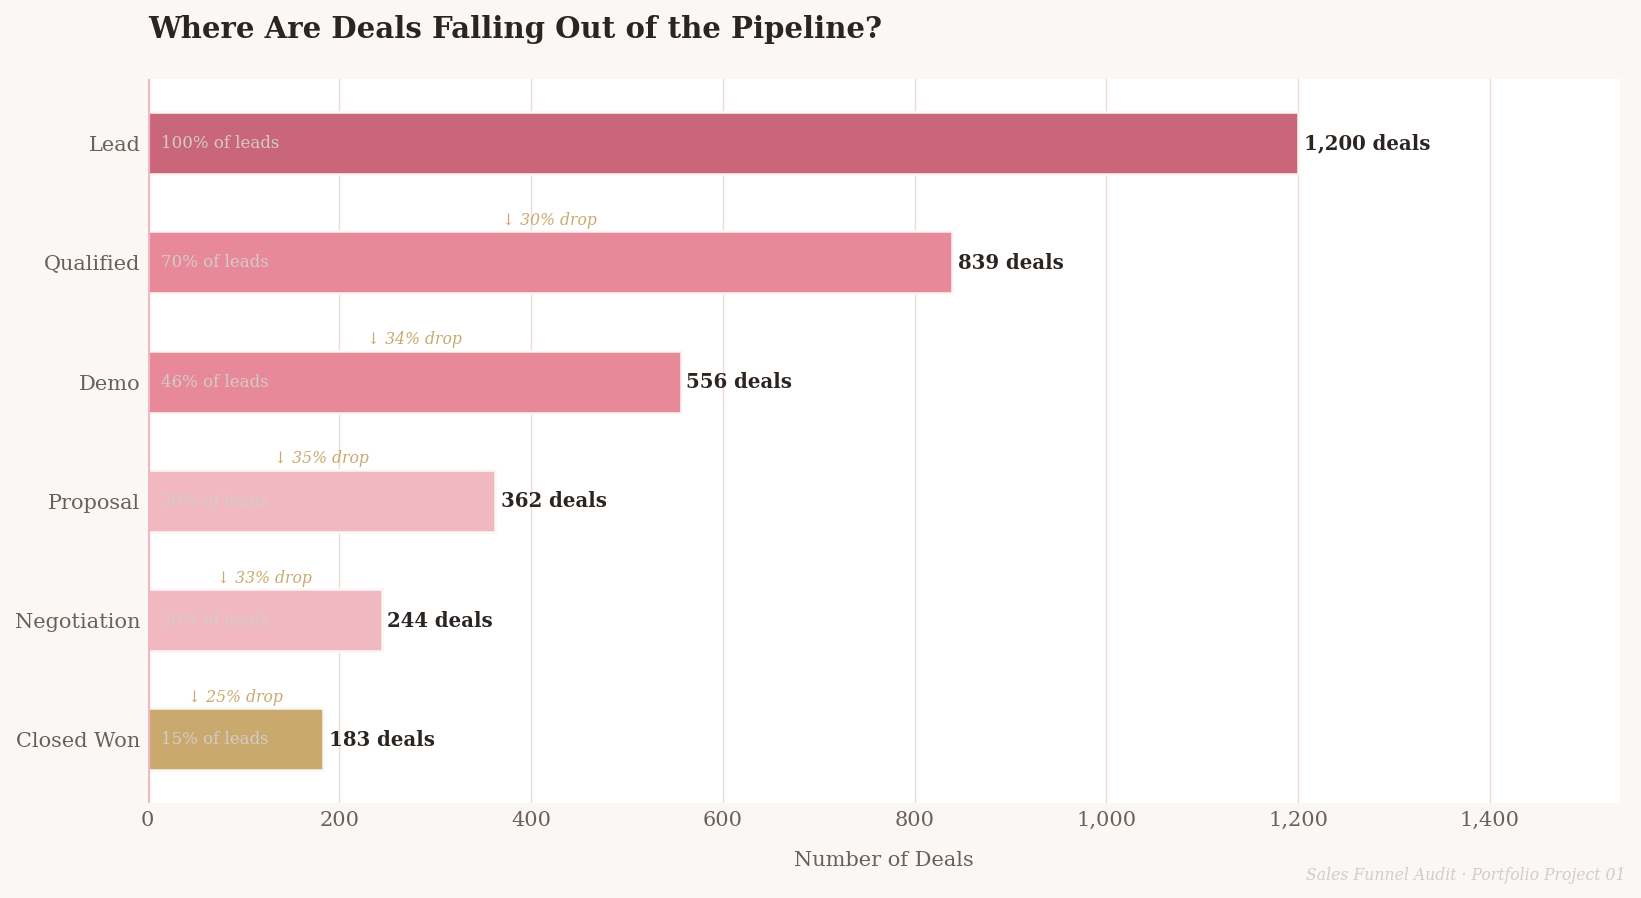

✓ Chart 1 saved


In [48]:
# ── CHART 1: FUNNEL DROP-OFF ──────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

PINK = {
    'deep'    : '#c9667a',
    'mid'     : '#e8899a',
    'soft'    : '#f2b8c2',
    'blush'   : '#fce8ec',
    'wash'    : '#fef6f7',
    'gold'    : '#c9a96e',
    'loss'    : '#c75555',
    'charcoal': '#2c2420',
    'warm'    : '#6b5f5a',
    'light'   : '#d4ccc9',
    'cream'   : '#faf7f5',
    'white'   : '#ffffff',
    'border'  : '#ecddd9',
}

plt.rcParams.update({
    'figure.facecolor' : PINK['cream'],
    'axes.facecolor'   : PINK['white'],
    'axes.labelcolor'  : PINK['warm'],
    'axes.titlecolor'  : PINK['charcoal'],
    'xtick.color'      : PINK['warm'],
    'ytick.color'      : PINK['warm'],
    'text.color'       : PINK['charcoal'],
    'grid.color'       : PINK['border'],
    'grid.linewidth'   : 0.7,
    'font.family'      : 'serif',
    'font.size'        : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.spines.left' : False,
    'axes.spines.bottom': False,
    'figure.dpi'       : 150,
})

df = pd.read_csv('pipeline_clean.csv')
stage_order = ['Lead','Qualified','Demo','Proposal',
               'Negotiation','Closed Won','Closed Lost']
df['stage'] = pd.Categorical(df['stage'],
                              categories=stage_order,
                              ordered=True)

active_stages = ['Lead','Qualified','Demo',
                 'Proposal','Negotiation','Closed Won']
counts = [df[df['stage'] >= s].shape[0] for s in active_stages]
drops  = [(1 - counts[i]/counts[i-1])*100
          for i in range(1, len(counts))]

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(PINK['cream'])

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)
ax.set_facecolor(PINK['white'])

bar_palette = [PINK['deep'], PINK['mid'], PINK['mid'],
               PINK['soft'], PINK['soft'], PINK['gold']]
bars = ax.barh(active_stages, counts,
               color=bar_palette,
               height=0.52, zorder=3,
               edgecolor=PINK['cream'],
               linewidth=1.2)

# Count labels
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 6,
            bar.get_y() + bar.get_height()/2,
            f'{count:,} deals',
            va='center',
            color=PINK['charcoal'],
            fontsize=9.5,
            fontweight='bold')

# % of original surviving
for i, count in enumerate(counts):
    pct = count / counts[0] * 100
    ax.text(14, i,
            f'{pct:.0f}% of leads',
            va='center',
            color=PINK['light'],
            fontsize=8)

# Drop-off annotations
for i, drop in enumerate(drops):
    color = PINK['loss'] if drop > 35 else PINK['gold']
    ax.text(counts[i+1]/2, i + 0.68,
            f'↓ {drop:.0f}% drop',
            ha='center',
            color=color,
            fontsize=7.5,
            style='italic')

ax.axvline(0, color=PINK['soft'], linewidth=2, zorder=5)
ax.set_title('Where Are Deals Falling Out of the Pipeline?',
             fontsize=14, fontweight='bold',
             pad=20, loc='left',
             color=PINK['charcoal'])
ax.set_xlabel('Number of Deals',
              color=PINK['warm'], labelpad=10)
ax.invert_yaxis()
ax.set_xlim(0, max(counts) * 1.28)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', color=PINK['border'], linewidth=0.7)
ax.grid(axis='y', visible=False)

fig.text(0.99, 0.01,
         'Sales Funnel Audit · Portfolio Project 01',
         ha='right', va='bottom',
         fontsize=7.5, color=PINK['light'],
         style='italic')

plt.tight_layout()
plt.savefig('chart1_funnel.png', dpi=180,
            bbox_inches='tight',
            facecolor=PINK['cream'])
plt.show()
print("✓ Chart 1 saved")

### Chart 2 — Win Rate by Lead Source
Business question: "Which acquisition channel actually closes deals?"
Volume alone is a vanity metric. This chart separates channels that
generate noise from channels that generate revenue.

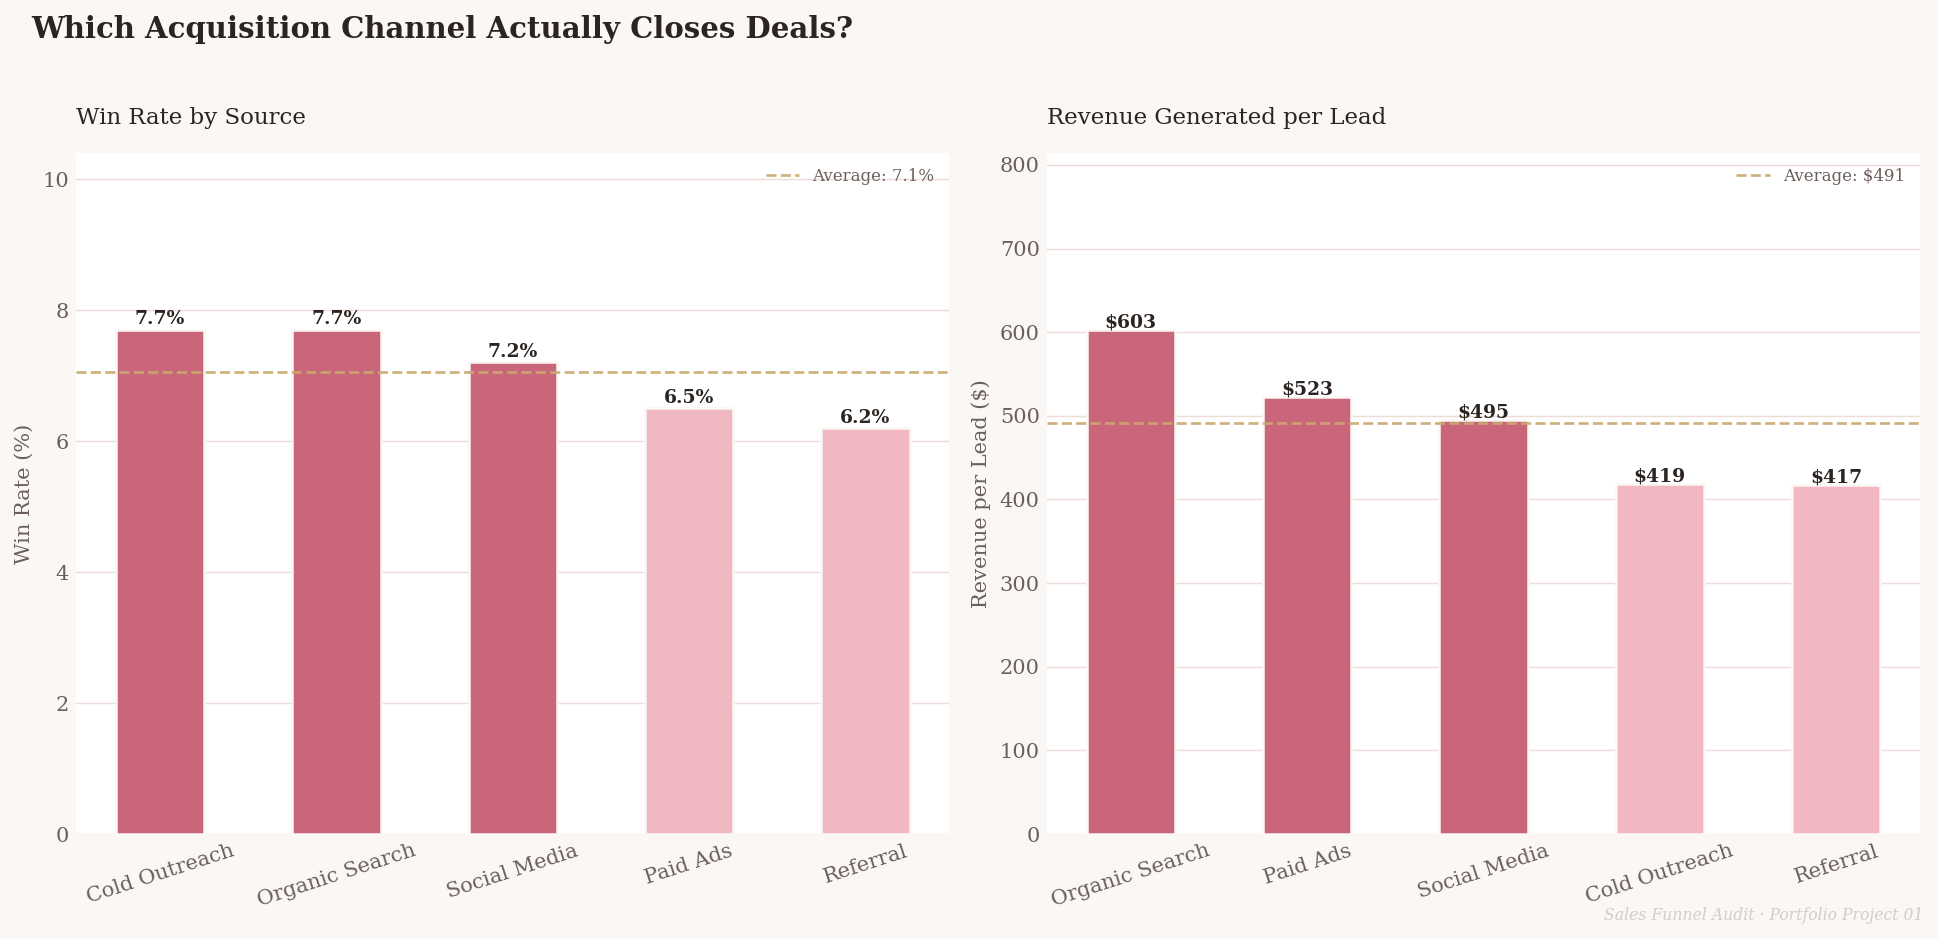

✓ Chart 2 saved


In [55]:
#  CHART 2: WIN RATE BY LEAD SOURCE
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

PINK = {
    'deep'    : '#c9667a',
    'mid'     : '#e8899a',
    'soft'    : '#f2b8c2',
    'blush'   : '#fce8ec',
    'wash'    : '#fef6f7',
    'gold'    : '#c9a96e',
    'loss'    : '#c75555',
    'charcoal': '#2c2420',
    'warm'    : '#6b5f5a',
    'light'   : '#d4ccc9',
    'cream'   : '#faf7f5',
    'white'   : '#ffffff',
    'border'  : '#ecddd9',
}

plt.rcParams.update({
    'figure.facecolor' : PINK['cream'],
    'axes.facecolor'   : PINK['white'],
    'axes.labelcolor'  : PINK['warm'],
    'axes.titlecolor'  : PINK['charcoal'],
    'xtick.color'      : PINK['warm'],
    'ytick.color'      : PINK['warm'],
    'text.color'       : PINK['charcoal'],
    'grid.color'       : PINK['border'],
    'font.family'      : 'serif',
    'font.size'        : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.spines.left' : False,
    'axes.spines.bottom': False,
    'figure.dpi'       : 150,
})

df = pd.read_csv('pipeline_clean.csv')
df['is_won'] = (df['stage'] == 'Closed Won').astype(int)

source_win   = (df.groupby('source')['is_won'].mean() * 100).round(1)
rev_per_lead = (df[df['is_won']==1]
                .groupby('source')['deal_value'].sum() /
                df.groupby('source')['lead_id'].count()).round(0)

source_df = pd.DataFrame({
    'win_rate'        : source_win,
    'revenue_per_lead': rev_per_lead
}).sort_values('win_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor(PINK['cream'])
fig.suptitle('Which Acquisition Channel Actually Closes Deals?',
             fontsize=14, fontweight='bold',
             color=PINK['charcoal'], x=0.02,
             ha='left', y=1.02)

for ax in axes:
    ax.set_facecolor(PINK['white'])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

# ── Left: Win Rate ────────────────────────────────────────────────────
ax1 = axes[0]
colors1 = [PINK['deep'] if v >= source_win.mean()
           else PINK['soft'] for v in source_df['win_rate']]
bars1 = ax1.bar(source_df.index, source_df['win_rate'],
                color=colors1, width=0.5, zorder=3,
                edgecolor=PINK['cream'], linewidth=1.2)

ax1.axhline(source_win.mean(),
            color=PINK['gold'], linestyle='--',
            linewidth=1.3, alpha=0.9,
            label=f'Average: {source_win.mean():.1f}%',
            zorder=4)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.08,
             f'{bar.get_height():.1f}%',
             ha='center', fontsize=9,
             color=PINK['charcoal'],
             fontweight='bold')

ax1.set_title('Win Rate by Source',
              fontsize=11, pad=14,
              color=PINK['charcoal'], loc='left')
ax1.set_ylabel('Win Rate (%)', color=PINK['warm'])
ax1.tick_params(axis='x', rotation=18)
ax1.legend(framealpha=0, fontsize=8,
           labelcolor=PINK['warm'])
ax1.set_ylim(0, source_df['win_rate'].max() * 1.35)
ax1.grid(axis='y', color=PINK['border'])
ax1.grid(axis='x', visible=False)

# ── Right: Revenue per Lead ───────────────────────────────────────────
ax2 = axes[1]
rev_sorted = source_df.sort_values('revenue_per_lead',
                                    ascending=False)
colors2 = [PINK['deep'] if v >= rev_per_lead.mean()
           else PINK['soft']
           for v in rev_sorted['revenue_per_lead']]
bars2 = ax2.bar(rev_sorted.index,
                rev_sorted['revenue_per_lead'],
                color=colors2, width=0.5, zorder=3,
                edgecolor=PINK['cream'], linewidth=1.2)

ax2.axhline(rev_per_lead.mean(),
            color=PINK['gold'], linestyle='--',
            linewidth=1.3, alpha=0.9,
            label=f'Average: ${rev_per_lead.mean():,.0f}',
            zorder=4)

for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 3,
             f'${bar.get_height():,.0f}',
             ha='center', fontsize=9,
             color=PINK['charcoal'],
             fontweight='bold')

ax2.set_title('Revenue Generated per Lead',
              fontsize=11, pad=14,
              color=PINK['charcoal'], loc='left')
ax2.set_ylabel('Revenue per Lead ($)', color=PINK['warm'])
ax2.tick_params(axis='x', rotation=18)
ax2.legend(framealpha=0, fontsize=8,
           labelcolor=PINK['warm'])
ax2.set_ylim(0, rev_sorted['revenue_per_lead'].max() * 1.35)
ax2.grid(axis='y', color=PINK['border'])
ax2.grid(axis='x', visible=False)

fig.text(0.99, 0.01,
         'Sales Funnel Audit · Portfolio Project 01',
         ha='right', va='bottom',
         fontsize=7.5, color=PINK['light'],
         style='italic')

plt.tight_layout()
plt.savefig('chart2_source.png', dpi=180,
            bbox_inches='tight',
            facecolor=PINK['cream'])
plt.show()
print("✓ Chart 2 saved")

### Chart 3 — Revenue at Risk Heatmap
Business question: "Where is money going stale in the pipeline?"
A heatmap reveals concentration of at-risk value across both stage
and deal age simultaneously, this is something a bar chart cannot show.

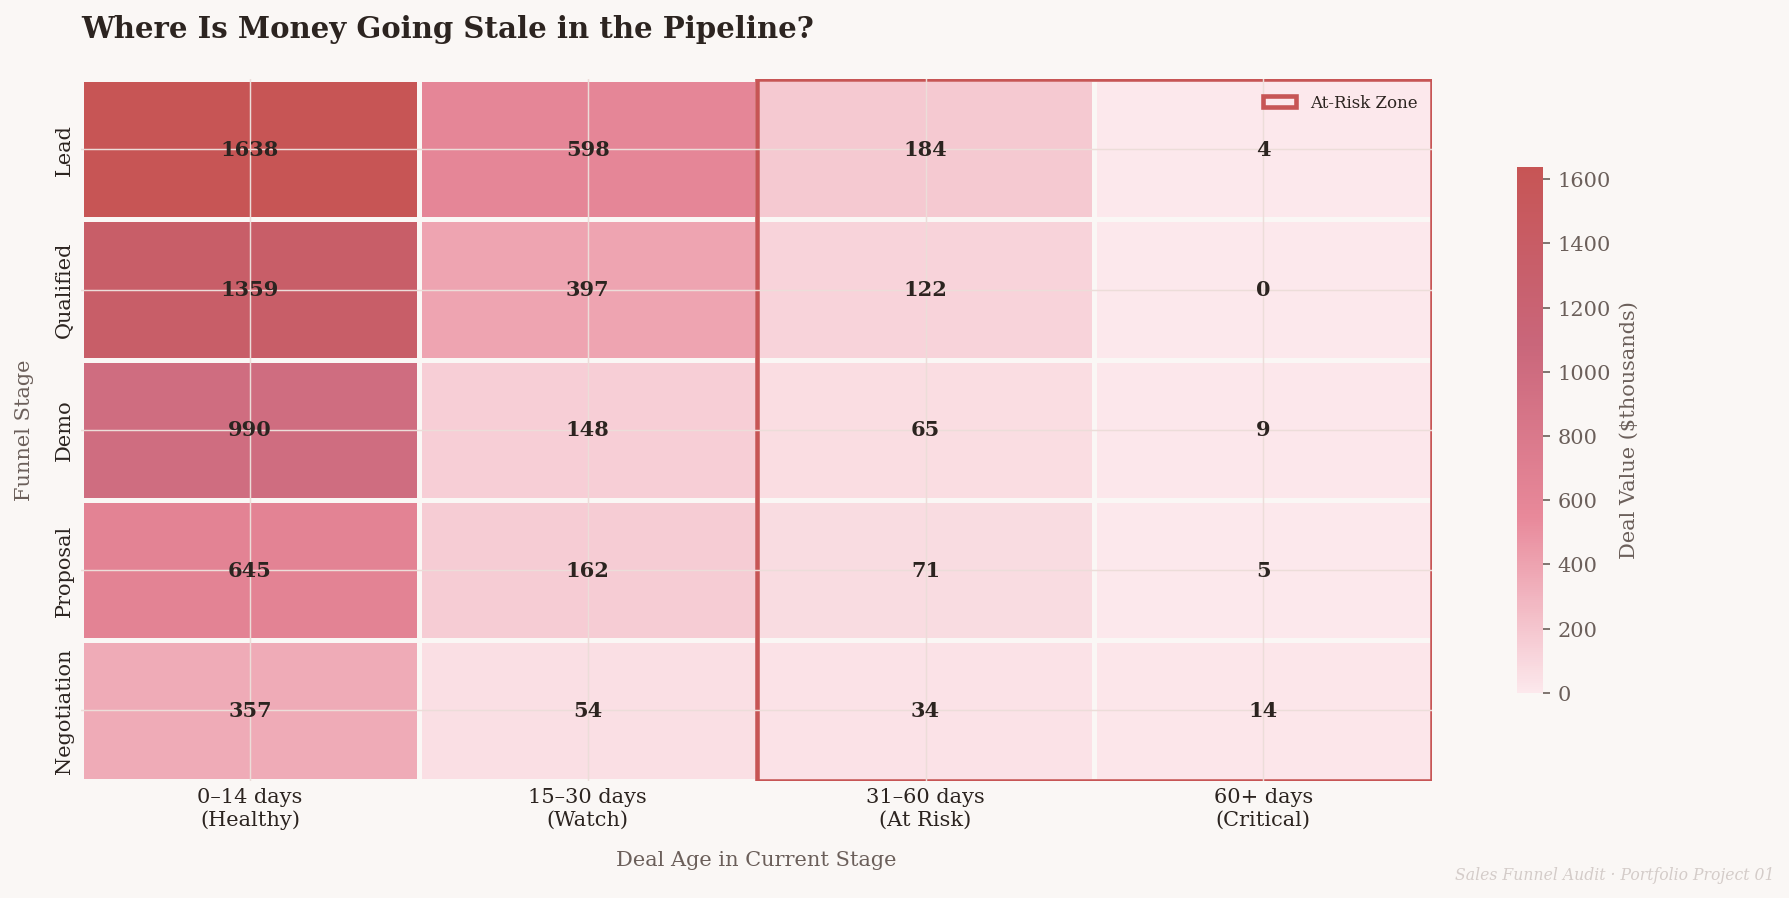

✓ Chart 3 saved


In [56]:
# CHART 3: REVENUE AT RISK HEATMAP
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

PINK = {
    'deep'    : '#c9667a',
    'mid'     : '#e8899a',
    'soft'    : '#f2b8c2',
    'blush'   : '#fce8ec',
    'wash'    : '#fef6f7',
    'gold'    : '#c9a96e',
    'loss'    : '#c75555',
    'charcoal': '#2c2420',
    'warm'    : '#6b5f5a',
    'light'   : '#d4ccc9',
    'cream'   : '#faf7f5',
    'white'   : '#ffffff',
    'border'  : '#ecddd9',
}

plt.rcParams.update({
    'figure.facecolor' : PINK['cream'],
    'axes.facecolor'   : PINK['white'],
    'axes.labelcolor'  : PINK['warm'],
    'axes.titlecolor'  : PINK['charcoal'],
    'xtick.color'      : PINK['warm'],
    'ytick.color'      : PINK['warm'],
    'text.color'       : PINK['charcoal'],
    'font.family'      : 'serif',
    'font.size'        : 10,
    'figure.dpi'       : 150,
})

df = pd.read_csv('pipeline_clean.csv')
stage_order = ['Lead','Qualified','Demo','Proposal',
               'Negotiation','Closed Won','Closed Lost']
df['stage'] = pd.Categorical(df['stage'],
                              categories=stage_order,
                              ordered=True)
df['is_active'] = (~df['stage'].isin(
    ['Closed Won','Closed Lost'])).astype(int)

active_df = df[df['is_active'] == 1].copy()
active_df['age_bucket'] = pd.cut(
    active_df['days_in_stage'],
    bins=[0, 14, 30, 60, float('inf')],
    labels=['0–14 days\n(Healthy)',
            '15–30 days\n(Watch)',
            '31–60 days\n(At Risk)',
            '60+ days\n(Critical)'])

heatmap_data = (active_df.pivot_table(
    index='stage',
    columns='age_bucket',
    values='deal_value',
    aggfunc='sum',
    observed=True)
    .reindex(['Lead','Qualified','Demo',
              'Proposal','Negotiation'])
    .fillna(0))

risk_cmap = LinearSegmentedColormap.from_list(
    'pink_risk',
    [PINK['blush'], PINK['mid'],
     PINK['deep'], PINK['loss']])

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(PINK['cream'])

sns.heatmap(heatmap_data / 1000,
            ax=ax,
            cmap=risk_cmap,
            annot=True,
            fmt='.0f',
            linewidths=1.5,
            linecolor=PINK['cream'],
            annot_kws={'size': 10,
                       'color': PINK['charcoal'],
                       'fontweight': 'bold'},
            cbar_kws={'label': 'Deal Value ($thousands)',
                      'shrink': 0.75})

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color(PINK['warm'])
cbar.ax.tick_params(colors=PINK['warm'])
cbar.outline.set_edgecolor(PINK['border'])

ax.add_patch(plt.Rectangle(
    (2, 0), 2, 5,
    fill=False,
    edgecolor=PINK['loss'],
    linewidth=2.2,
    label='At-Risk Zone'))
ax.legend(loc='upper right',
          framealpha=0,
          fontsize=8,
          labelcolor=PINK['charcoal'])

ax.set_title('Where Is Money Going Stale in the Pipeline?',
             fontsize=14, fontweight='bold',
             pad=20, loc='left',
             color=PINK['charcoal'])
ax.set_xlabel('Deal Age in Current Stage',
              color=PINK['warm'], labelpad=10)
ax.set_ylabel('Funnel Stage',
              color=PINK['warm'], labelpad=10)
ax.tick_params(colors=PINK['charcoal'], length=0)

fig.text(0.99, 0.01,
         'Sales Funnel Audit · Portfolio Project 01',
         ha='right', va='bottom',
         fontsize=7.5, color=PINK['light'],
         style='italic')

plt.tight_layout()
plt.savefig('chart3_heatmap.png', dpi=180,
            bbox_inches='tight',
            facecolor=PINK['cream'])
plt.show()
print("✓ Chart 3 saved")

### Chart 4 — Monthly Pipeline Trend
Business question: "Is the pipeline growing or shrinking over time?"
The relationship between new leads entering and deals closing each month
reveals whether the business is building momentum or running on empty.

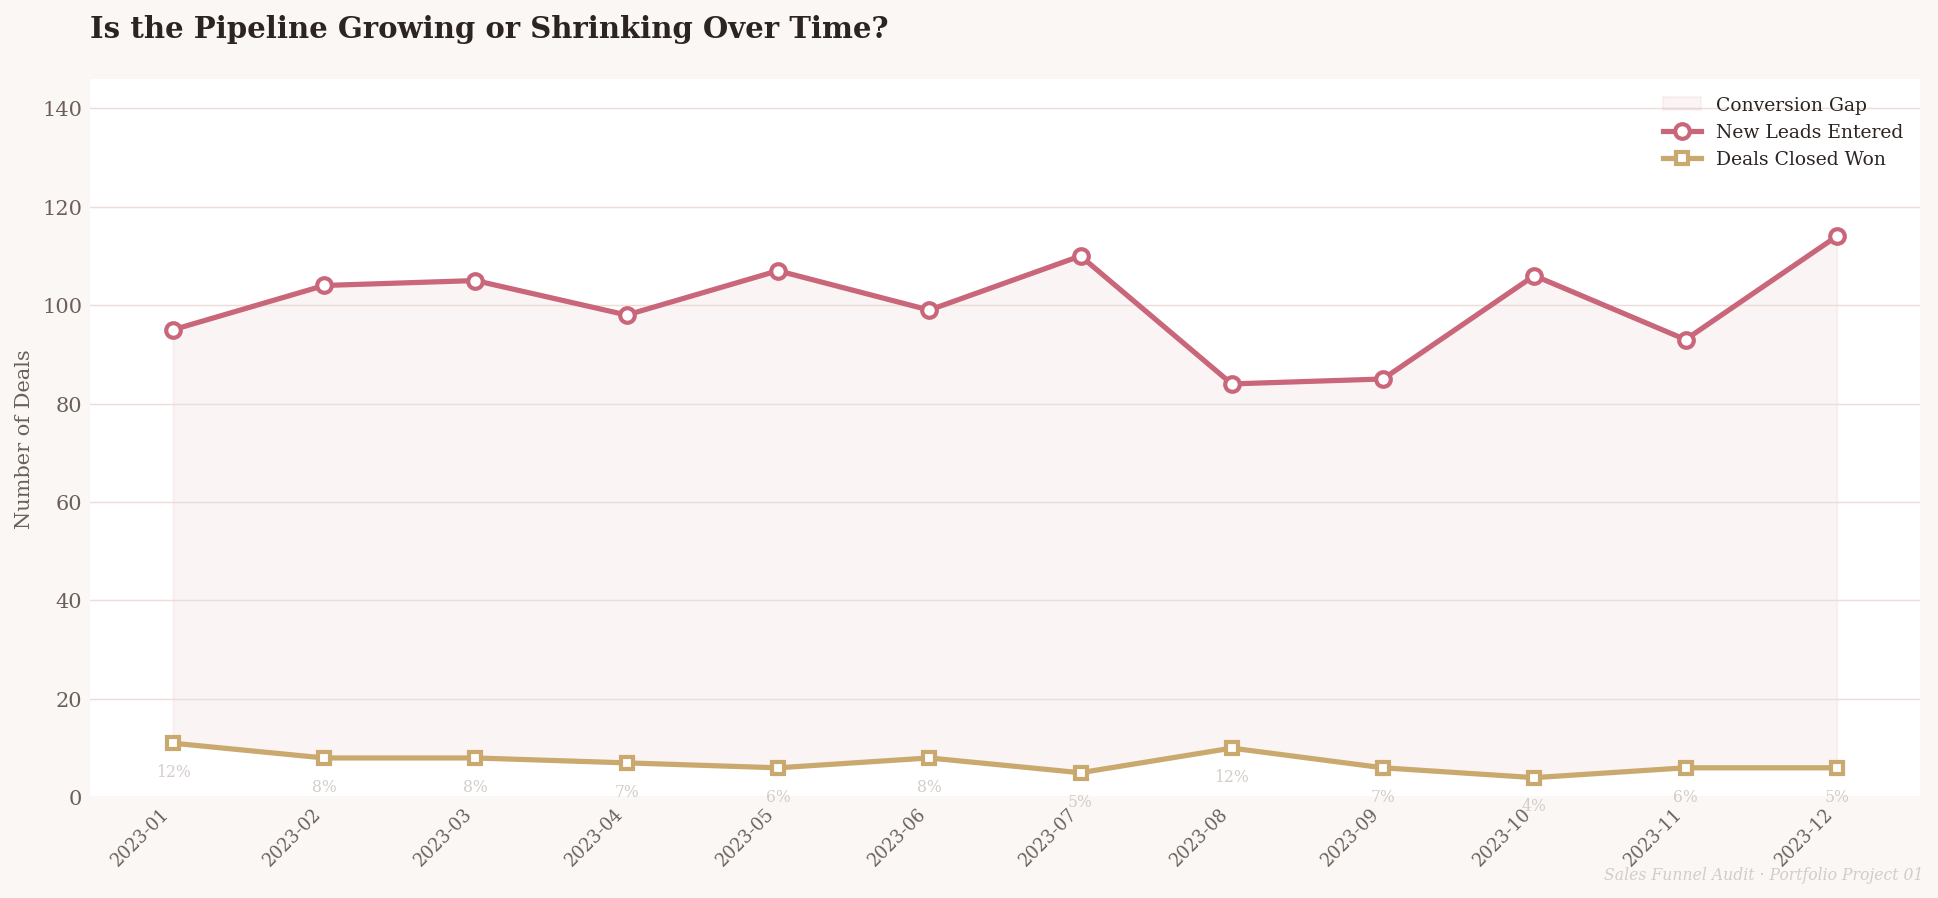

✓ Chart 4 saved


In [57]:
# CHART 4: MONTHLY PIPELINE TREND
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

PINK = {
    'deep'    : '#c9667a',
    'mid'     : '#e8899a',
    'soft'    : '#f2b8c2',
    'blush'   : '#fce8ec',
    'gold'    : '#c9a96e',
    'charcoal': '#2c2420',
    'warm'    : '#6b5f5a',
    'light'   : '#d4ccc9',
    'cream'   : '#faf7f5',
    'white'   : '#ffffff',
    'border'  : '#ecddd9',
}

plt.rcParams.update({
    'figure.facecolor' : PINK['cream'],
    'axes.facecolor'   : PINK['white'],
    'axes.labelcolor'  : PINK['warm'],
    'axes.titlecolor'  : PINK['charcoal'],
    'xtick.color'      : PINK['warm'],
    'ytick.color'      : PINK['warm'],
    'text.color'       : PINK['charcoal'],
    'grid.color'       : PINK['border'],
    'font.family'      : 'serif',
    'font.size'        : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.spines.left' : False,
    'axes.spines.bottom': False,
    'figure.dpi'       : 150,
})

df = pd.read_csv('pipeline_clean.csv')
df['created_date'] = pd.to_datetime(df['created_date'])
df['month']   = df['created_date'].dt.to_period('M')
df['is_won']  = (df['stage'] == 'Closed Won').astype(int)

monthly_leads = (df.groupby('month').size()
                   .reset_index(name='new_leads'))
monthly_won   = (df[df['is_won']==1]
                   .groupby('month').size()
                   .reset_index(name='closed_won'))
monthly = monthly_leads.merge(monthly_won,
                               on='month', how='left')
monthly['closed_won'] = monthly['closed_won'].fillna(0)
monthly['month_str']  = monthly['month'].astype(str)

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(PINK['cream'])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)
ax.set_facecolor(PINK['white'])

x = range(len(monthly))

ax.fill_between(x,
                monthly['new_leads'],
                monthly['closed_won'],
                alpha=0.07,
                color=PINK['deep'],
                label='Conversion Gap')

ax.plot(x, monthly['new_leads'],
        color=PINK['deep'],
        linewidth=2.5,
        marker='o', markersize=7,
        markerfacecolor=PINK['white'],
        markeredgecolor=PINK['deep'],
        markeredgewidth=2,
        label='New Leads Entered',
        zorder=4)

ax.plot(x, monthly['closed_won'],
        color=PINK['gold'],
        linewidth=2.5,
        marker='s', markersize=6,
        markerfacecolor=PINK['white'],
        markeredgecolor=PINK['gold'],
        markeredgewidth=2,
        label='Deals Closed Won',
        zorder=4)

for i, row in monthly.iterrows():
    if row['new_leads'] > 0:
        rate = row['closed_won'] / row['new_leads'] * 100
        ax.annotate(f'{rate:.0f}%',
                    xy=(i, row['closed_won']),
                    xytext=(0, -16),
                    textcoords='offset points',
                    ha='center',
                    fontsize=7.5,
                    color=PINK['light'])

ax.set_xticks(list(x))
ax.set_xticklabels(monthly['month_str'],
                   rotation=45, ha='right',
                   fontsize=8.5)
ax.set_title('Is the Pipeline Growing or Shrinking Over Time?',
             fontsize=14, fontweight='bold',
             pad=20, loc='left',
             color=PINK['charcoal'])
ax.set_ylabel('Number of Deals', color=PINK['warm'])
ax.legend(framealpha=0, fontsize=9,
          labelcolor=PINK['charcoal'])
ax.set_ylim(0, monthly['new_leads'].max() * 1.28)
ax.grid(axis='y', color=PINK['border'])
ax.grid(axis='x', visible=False)

fig.text(0.99, 0.01,
         'Sales Funnel Audit · Portfolio Project 01',
         ha='right', va='bottom',
         fontsize=7.5, color=PINK['light'],
         style='italic')

plt.tight_layout()
plt.savefig('chart4_trend.png', dpi=180,
            bbox_inches='tight',
            facecolor=PINK['cream'])
plt.show()
print("✓ Chart 4 saved")

### Chart 5 — Deal Value Distribution by Segment
Business question: "Which customer segment is actually worth chasing?"
A box plot reveals not just averages but spread, outliers, and
consistency, the full picture of value distribution that a single
average number hides completely.

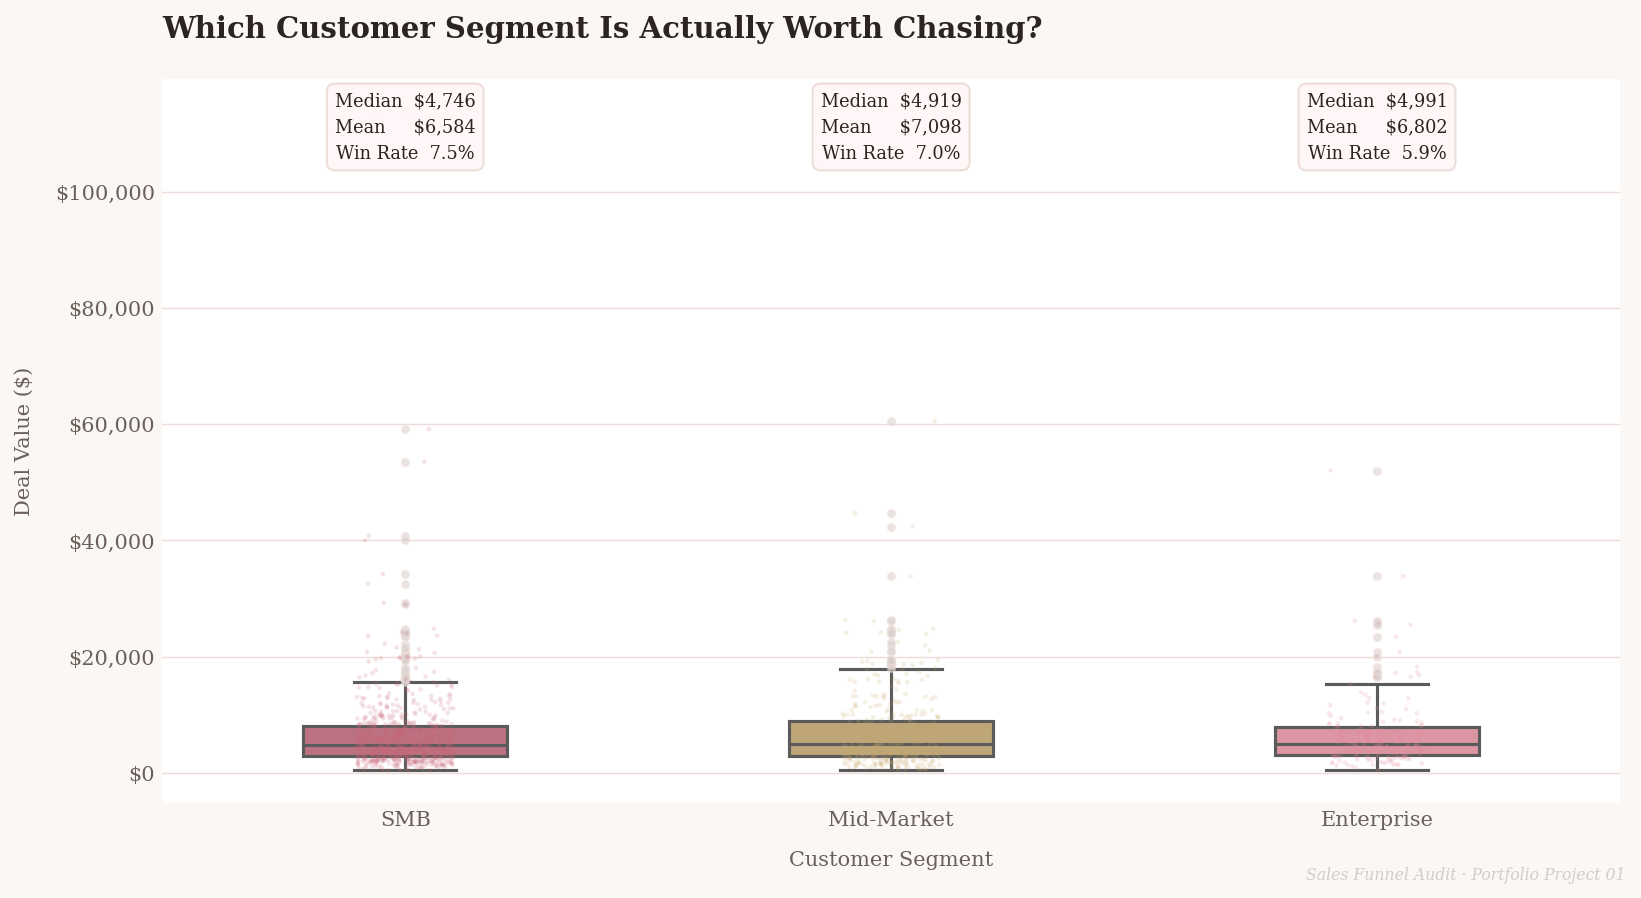

✓ Chart 5 saved


In [58]:
# CHART 5: DEAL VALUE BY SEGMENT (BOX PLOT)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

PINK = {
    'deep'    : '#c9667a',
    'mid'     : '#e8899a',
    'soft'    : '#f2b8c2',
    'blush'   : '#fce8ec',
    'wash'    : '#fef6f7',
    'gold'    : '#c9a96e',
    'charcoal': '#2c2420',
    'warm'    : '#6b5f5a',
    'light'   : '#d4ccc9',
    'cream'   : '#faf7f5',
    'white'   : '#ffffff',
    'border'  : '#ecddd9',
}

plt.rcParams.update({
    'figure.facecolor' : PINK['cream'],
    'axes.facecolor'   : PINK['white'],
    'axes.labelcolor'  : PINK['warm'],
    'axes.titlecolor'  : PINK['charcoal'],
    'xtick.color'      : PINK['warm'],
    'ytick.color'      : PINK['warm'],
    'text.color'       : PINK['charcoal'],
    'grid.color'       : PINK['border'],
    'font.family'      : 'serif',
    'font.size'        : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.spines.left' : False,
    'axes.spines.bottom': False,
    'figure.dpi'       : 150,
})

df = pd.read_csv('pipeline_clean.csv')
df['is_won'] = (df['stage'] == 'Closed Won').astype(int)

segment_order = ['SMB', 'Mid-Market', 'Enterprise']
palette = {
    'SMB'        : PINK['deep'],
    'Mid-Market' : PINK['gold'],
    'Enterprise' : PINK['mid']
}

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(PINK['cream'])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)
ax.set_facecolor(PINK['white'])

sns.boxplot(data=df,
            x='segment', y='deal_value',
            order=segment_order,
            palette=palette,
            width=0.42,
            linewidth=1.5,
            flierprops=dict(
                marker='o',
                markerfacecolor=PINK['light'],
                markeredgecolor=PINK['border'],
                markersize=3.5,
                alpha=0.5),
            ax=ax)

sns.stripplot(data=df,
              x='segment', y='deal_value',
              order=segment_order,
              palette=palette,
              size=2.2,
              alpha=0.18,
              jitter=True,
              ax=ax)

for i, seg in enumerate(segment_order):
    seg_data = df[df['segment'] == seg]['deal_value']
    median   = seg_data.median()
    mean     = seg_data.mean()
    win_rate = df[df['segment']==seg]['is_won'].mean() * 100
    ax.text(i, df['deal_value'].max() * 0.93,
            f'Median  ${median:,.0f}\n'
            f'Mean     ${mean:,.0f}\n'
            f'Win Rate  {win_rate:.1f}%',
            ha='center', fontsize=8.5,
            color=PINK['charcoal'],
            linespacing=1.6,
            bbox=dict(boxstyle='round,pad=0.45',
                      facecolor=PINK['wash'],
                      edgecolor=PINK['border'],
                      alpha=0.95))

ax.set_title('Which Customer Segment Is Actually Worth Chasing?',
             fontsize=14, fontweight='bold',
             pad=20, loc='left',
             color=PINK['charcoal'])
ax.set_xlabel('Customer Segment',
              color=PINK['warm'], labelpad=10)
ax.set_ylabel('Deal Value ($)',
              color=PINK['warm'], labelpad=10)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', color=PINK['border'])
ax.grid(axis='x', visible=False)

fig.text(0.99, 0.01,
         'Sales Funnel Audit · Portfolio Project 01',
         ha='right', va='bottom',
         fontsize=7.5, color=PINK['light'],
         style='italic')

plt.tight_layout()
plt.savefig('chart5_segment.png', dpi=180,
            bbox_inches='tight',
            facecolor=PINK['cream'])
plt.show()
print("✓ Chart 5 saved")

In [59]:
from google.colab import files

for f in ['chart1_funnel.png','chart2_source.png',
          'chart3_heatmap.png','chart4_trend.png',
          'chart5_segment.png']:
    files.download(f)
    print(f"✓ {f} downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ chart1_funnel.png downloaded


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✓ chart4_trend.png downloaded


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ chart5_segment.png downloaded


### Phase 4 Summary — The Visual Story

Five charts. Five business questions answered visually.

Chart 1 confirmed that funnel attrition is steady and distributed  
no single catastrophic drop-off, but consistent bleeding at every stage
that compounds into a 15.2% end-to-end conversion rate.

Chart 2 revealed that lead source win rates are surprisingly uniform,
but Organic Search generates the highest revenue per lead through deal
quality rather than conversion volume.

Chart 3 identified the geographic concentration of at-risk revenue
across stage and deal age simultaneously — pinpointing exactly where
sales intervention will have the highest dollar impact.

Chart 4 showed the monthly relationship between pipeline entry and
deal closure — the persistent gap between these two lines is the
visual representation of the conversion problem quantified in Phase 3.

Chart 5 exposed the Enterprise underperformance story in its most
complete form — not just lower average values but a tighter, lower
distribution across the full range of deals compared to the wider
spread of SMB and Mid-Market outliers.

The complete visual suite is now ready to accompany the Insight Brief
in Phase 5.

## Phase 5 — Insight Brief
The deliverable that separates a strategist from a technician. A 1-page
executive summary written for a founder who has 100 seconds — not a data
team that has all day. Every number from the analysis compressed into a
document that drives a decision.

In [53]:
# ── INSIGHT BRIEF — GENERATE HTML FILE ───────────────────────────────
html_content = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Sales Funnel Audit — Insight Brief</title>
    <link href="https://fonts.googleapis.com/css2?family=Playfair+Display:wght@400;600;700&family=DM+Sans:wght@300;400;500&display=swap" rel="stylesheet">
    <style>
        :root {
            --pink-deep:    #c9667a;
            --pink-mid:     #e8899a;
            --pink-soft:    #f2b8c2;
            --pink-blush:   #fce8ec;
            --pink-wash:    #fef6f7;
            --gold:         #c9a96e;
            --charcoal:     #2c2420;
            --warm-grey:    #6b5f5a;
            --light-grey:   #d4ccc9;
            --cream:        #faf7f5;
            --white:        #ffffff;
            --border:       #ecddd9;
        }
        * { margin: 0; padding: 0; box-sizing: border-box; }
        body {
            background-color: var(--cream);
            color: var(--charcoal);
            font-family: 'DM Sans', sans-serif;
            font-weight: 300;
            min-height: 100vh;
            display: flex;
            justify-content: center;
            padding: 48px 20px 64px;
        }
        .page { width: 100%; max-width: 780px; }
        .topbar {
            display: flex;
            justify-content: space-between;
            align-items: center;
            margin-bottom: 48px;
            padding-bottom: 20px;
            border-bottom: 1px solid var(--border);
        }
        .topbar-left {
            font-size: 11px;
            font-weight: 500;
            letter-spacing: 0.18em;
            text-transform: uppercase;
            color: var(--pink-deep);
        }
        .topbar-right {
            font-size: 11px;
            color: var(--warm-grey);
            letter-spacing: 0.05em;
        }
        .hero { margin-bottom: 52px; }
        .hero-eyebrow {
            font-size: 11px;
            font-weight: 500;
            letter-spacing: 0.2em;
            text-transform: uppercase;
            color: var(--pink-deep);
            margin-bottom: 14px;
            display: flex;
            align-items: center;
            gap: 10px;
        }
        .hero-eyebrow::before {
            content: '';
            display: inline-block;
            width: 28px;
            height: 1px;
            background-color: var(--pink-deep);
        }
        .hero h1 {
            font-family: 'Playfair Display', serif;
            font-size: 42px;
            font-weight: 700;
            line-height: 1.15;
            color: var(--charcoal);
            margin-bottom: 18px;
            letter-spacing: -0.01em;
        }
        .hero h1 em { font-style: normal; color: var(--pink-deep); }
        .hero-meta { display: flex; gap: 10px; flex-wrap: wrap; }
        .meta-pill {
            font-size: 11px;
            font-weight: 500;
            letter-spacing: 0.08em;
            padding: 5px 12px;
            border-radius: 20px;
            background-color: var(--pink-blush);
            color: var(--pink-deep);
            border: 1px solid var(--pink-soft);
        }
        .divider {
            width: 100%;
            height: 1px;
            background: linear-gradient(to right, var(--pink-soft), transparent);
            margin: 40px 0;
        }
        .section { margin-bottom: 44px; }
        .section-header {
            display: flex;
            align-items: baseline;
            gap: 12px;
            margin-bottom: 20px;
        }
        .section-num {
            font-family: 'Playfair Display', serif;
            font-size: 13px;
            font-weight: 600;
            color: var(--pink-soft);
            letter-spacing: 0.05em;
        }
        .section-title {
            font-size: 11px;
            font-weight: 500;
            letter-spacing: 0.2em;
            text-transform: uppercase;
            color: var(--warm-grey);
        }
        .situation-text {
            font-size: 15px;
            line-height: 1.85;
            color: var(--charcoal);
            font-weight: 300;
            max-width: 680px;
            padding-left: 20px;
            border-left: 2px solid var(--pink-soft);
        }
        .finding {
            display: grid;
            grid-template-columns: 36px 1fr;
            gap: 0 18px;
            margin-bottom: 18px;
            padding: 20px 24px;
            background-color: var(--white);
            border-radius: 10px;
            border: 1px solid var(--border);
        }
        .finding-num {
            font-family: 'Playfair Display', serif;
            font-size: 28px;
            font-weight: 700;
            color: var(--pink-blush);
            line-height: 1;
            padding-top: 2px;
        }
        .finding-headline {
            font-size: 13.5px;
            font-weight: 500;
            color: var(--charcoal);
            margin-bottom: 6px;
            line-height: 1.4;
        }
        .finding-detail {
            font-size: 13px;
            line-height: 1.75;
            color: var(--warm-grey);
            font-weight: 300;
        }
        .finding-detail strong { color: var(--pink-deep); font-weight: 500; }
        .impact-grid {
            display: grid;
            grid-template-columns: repeat(3, 1fr);
            gap: 14px;
        }
        .impact-card {
            background-color: var(--white);
            border: 1px solid var(--border);
            border-radius: 10px;
            padding: 22px 18px;
            text-align: center;
        }
        .impact-card.loss  { border-top: 3px solid #e07070; }
        .impact-card.risk  { border-top: 3px solid var(--gold); }
        .impact-card.recover { border-top: 3px solid var(--pink-deep); }
        .impact-value {
            font-family: 'Playfair Display', serif;
            font-size: 26px;
            font-weight: 700;
            margin-bottom: 6px;
            line-height: 1;
        }
        .impact-card.loss    .impact-value { color: #c75555; }
        .impact-card.risk    .impact-value { color: var(--gold); }
        .impact-card.recover .impact-value { color: var(--pink-deep); }
        .impact-label {
            font-size: 11px;
            color: var(--warm-grey);
            line-height: 1.5;
        }
        .impact-note {
            margin-top: 14px;
            font-size: 12px;
            color: var(--warm-grey);
            line-height: 1.7;
            font-style: italic;
            padding: 12px 16px;
            background-color: var(--pink-wash);
            border-radius: 8px;
            border: 1px solid var(--pink-blush);
        }
        .recommendation {
            display: grid;
            grid-template-columns: 36px 1fr;
            gap: 0 18px;
            margin-bottom: 16px;
            padding: 22px 24px;
            background-color: var(--white);
            border-radius: 10px;
            border: 1px solid var(--border);
        }
        .rec-num {
            font-family: 'Playfair Display', serif;
            font-size: 28px;
            font-weight: 700;
            color: var(--pink-blush);
            line-height: 1;
            padding-top: 2px;
        }
        .rec-title {
            font-size: 12px;
            font-weight: 500;
            letter-spacing: 0.12em;
            text-transform: uppercase;
            color: var(--pink-deep);
            margin-bottom: 8px;
        }
        .rec-text {
            font-size: 13px;
            line-height: 1.8;
            color: var(--warm-grey);
            font-weight: 300;
        }
        .rec-text strong { color: var(--charcoal); font-weight: 500; }
        .footer {
            margin-top: 52px;
            padding-top: 22px;
            border-top: 1px solid var(--border);
            display: flex;
            justify-content: space-between;
            align-items: center;
            flex-wrap: wrap;
            gap: 12px;
        }
        .footer-left { font-size: 11px; color: var(--light-grey); }
        .footer-right { font-size: 11px; color: var(--pink-deep); font-weight: 500; }
    </style>
</head>
<body>
<div class="page">
    <div class="topbar">
        <div class="topbar-left">Portfolio Project 01 &nbsp;·&nbsp; Sales Funnel Audit</div>
        <div class="topbar-right">Python · Pandas · Matplotlib · Seaborn</div>
    </div>
    <div class="hero">
        <div class="hero-eyebrow">Executive Insight Brief</div>
        <h1>Where Is This Pipeline<br><em>Losing Revenue?</em></h1>
        <div class="hero-meta">
            <span class="meta-pill">1,200 Records</span>
            <span class="meta-pill">12 Months</span>
            <span class="meta-pill">B2B SaaS</span>
            <span class="meta-pill">6 Core Metrics</span>
        </div>
    </div>
    <div class="section">
        <div class="section-header">
            <span class="section-num">01</span>
            <span class="section-title">The Situation</span>
        </div>
        <p class="situation-text">
            This analysis examined 1,200 sales pipeline records from a B2B SaaS company
            across a full 12-month period. The goal was to identify precisely where revenue
            is being lost, quantify the dollar impact of those losses, and surface the
            three actions that would generate the highest return if prioritised immediately.
        </p>
    </div>
    <div class="divider"></div>
    <div class="section">
        <div class="section-header">
            <span class="section-num">02</span>
            <span class="section-title">Key Findings</span>
        </div>
        <div class="finding">
            <div class="finding-num">1</div>
            <div class="finding-body">
                <div class="finding-headline">The pipeline converts at 7.1% — less than half the industry minimum.</div>
                <div class="finding-detail">Stage-by-stage drop-off rates sit between 25–35% at every transition,
                producing an end-to-end Lead → Won rate of 15.2% and an overall win rate of
                <strong>7.1% against a healthy benchmark of 20–30%.</strong> There is no single
                catastrophic stage failure — five stages are each losing a third of their deals,
                compounding into a systemic underperformance problem across the entire funnel.</div>
            </div>
        </div>
        <div class="finding">
            <div class="finding-num">2</div>
            <div class="finding-body">
                <div class="finding-headline">$507,185 in active pipeline value has gone silent past 30 days.</div>
                <div class="finding-detail">85 deals are neither progressing nor formally closed — occupying
                sales capacity without moving toward revenue. <strong>10 of those deals sit at
                Negotiation stage</strong>, the closest point to closing in the entire funnel,
                making them the single highest-priority intervention target available right now.</div>
            </div>
        </div>
        <div class="finding">
            <div class="finding-num">3</div>
            <div class="finding-body">
                <div class="finding-headline">Enterprise is the worst performing segment on every metric simultaneously.</div>
                <div class="finding-detail">At a <strong>5.9% win rate and $401 expected value per lead</strong>,
                Enterprise underperforms both SMB (7.5% win rate, $494 per lead) and Mid-Market
                (7.0% win rate, $497 per lead) — despite typically receiving disproportionate
                sales time and resource investment.</div>
            </div>
        </div>
    </div>
    <div class="divider"></div>
    <div class="section">
        <div class="section-header">
            <span class="section-num">03</span>
            <span class="section-title">Revenue Impact</span>
        </div>
        <div class="impact-grid">
            <div class="impact-card loss">
                <div class="impact-value">$665,836</div>
                <div class="impact-label">Permanently lost<br>to Closed Lost deals</div>
            </div>
            <div class="impact-card risk">
                <div class="impact-value">$507,185</div>
                <div class="impact-label">At risk in stalled<br>active deals</div>
            </div>
            <div class="impact-card recover">
                <div class="impact-value">$35,926</div>
                <div class="impact-label">Estimated recoverable<br>if actioned this week</div>
            </div>
        </div>
        <p class="impact-note">
            The pipeline has already lost more to Closed Lost ($665,836) than it has closed
            as won revenue ($609,805). The gap between what entered this funnel and what
            converted to revenue is the core business problem this analysis addresses.
        </p>
    </div>
    <div class="divider"></div>
    <div class="section">
        <div class="section-header">
            <span class="section-num">04</span>
            <span class="section-title">Recommendations</span>
        </div>
        <div class="recommendation">
            <div class="rec-num">1</div>
            <div class="rec-body">
                <div class="rec-title">Launch a Negotiation Sprint — This Week</div>
                <div class="rec-text">The 10 stalled Negotiation deals represent the highest return per hour
                of sales effort in the entire pipeline. <strong>Assign a senior rep to contact all 10
                within 72 hours</strong> with a specific re-engagement offer — a limited-time pricing
                incentive or expedited onboarding commitment. These deals have already cleared every
                qualification hurdle. They need a reason to decide, not a reason to be interested.</div>
            </div>
        </div>
        <div class="recommendation">
            <div class="rec-num">2</div>
            <div class="rec-body">
                <div class="rec-title">Introduce a 5-Point Qualification Scorecard at Lead Stage</div>
                <div class="rec-text">30% of leads stall at the earliest stage before any meaningful sales
                work has been done. <strong>A mandatory 5-question scorecard covering budget, authority,
                need, timeline, and competitive alternatives</strong> before advancing any lead to Qualified
                would eliminate low-probability deals early — freeing reps to focus on Mid-Market where
                expected value per lead is highest at $497.</div>
            </div>
        </div>
        <div class="recommendation">
            <div class="rec-num">3</div>
            <div class="rec-body">
                <div class="rec-title">Audit Enterprise Pricing Before the Next Budget Cycle</div>
                <div class="rec-text">Enterprise deals are closing less often for less money than SMB deals —
                a direct contradiction of where most sales resources are invested.
                <strong>A pricing and capability audit before approving further Enterprise lead generation
                spend</strong> is essential. Reallocating just 20% of Enterprise-focused effort toward
                Mid-Market would be expected to generate more revenue based on current conversion data.</div>
            </div>
        </div>
    </div>
    <div class="footer">
        <div class="footer-left">Analysis · 1,200 synthetic CRM records · Python · Pandas · Matplotlib · Seaborn</div>
        <div class="footer-right">github.com/yourusername/saas-sales-funnel-audit</div>
    </div>
</div>
</body>
</html>
"""

with open('insight_brief.html', 'w') as f:
    f.write(html_content)

print("✓ Insight brief saved as insight_brief.html")

✓ Insight brief saved as insight_brief.html


In [54]:
from google.colab import files
files.download('insight_brief.html')
print("✓ Download started — open in your browser to view")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download started — open in your browser to view
